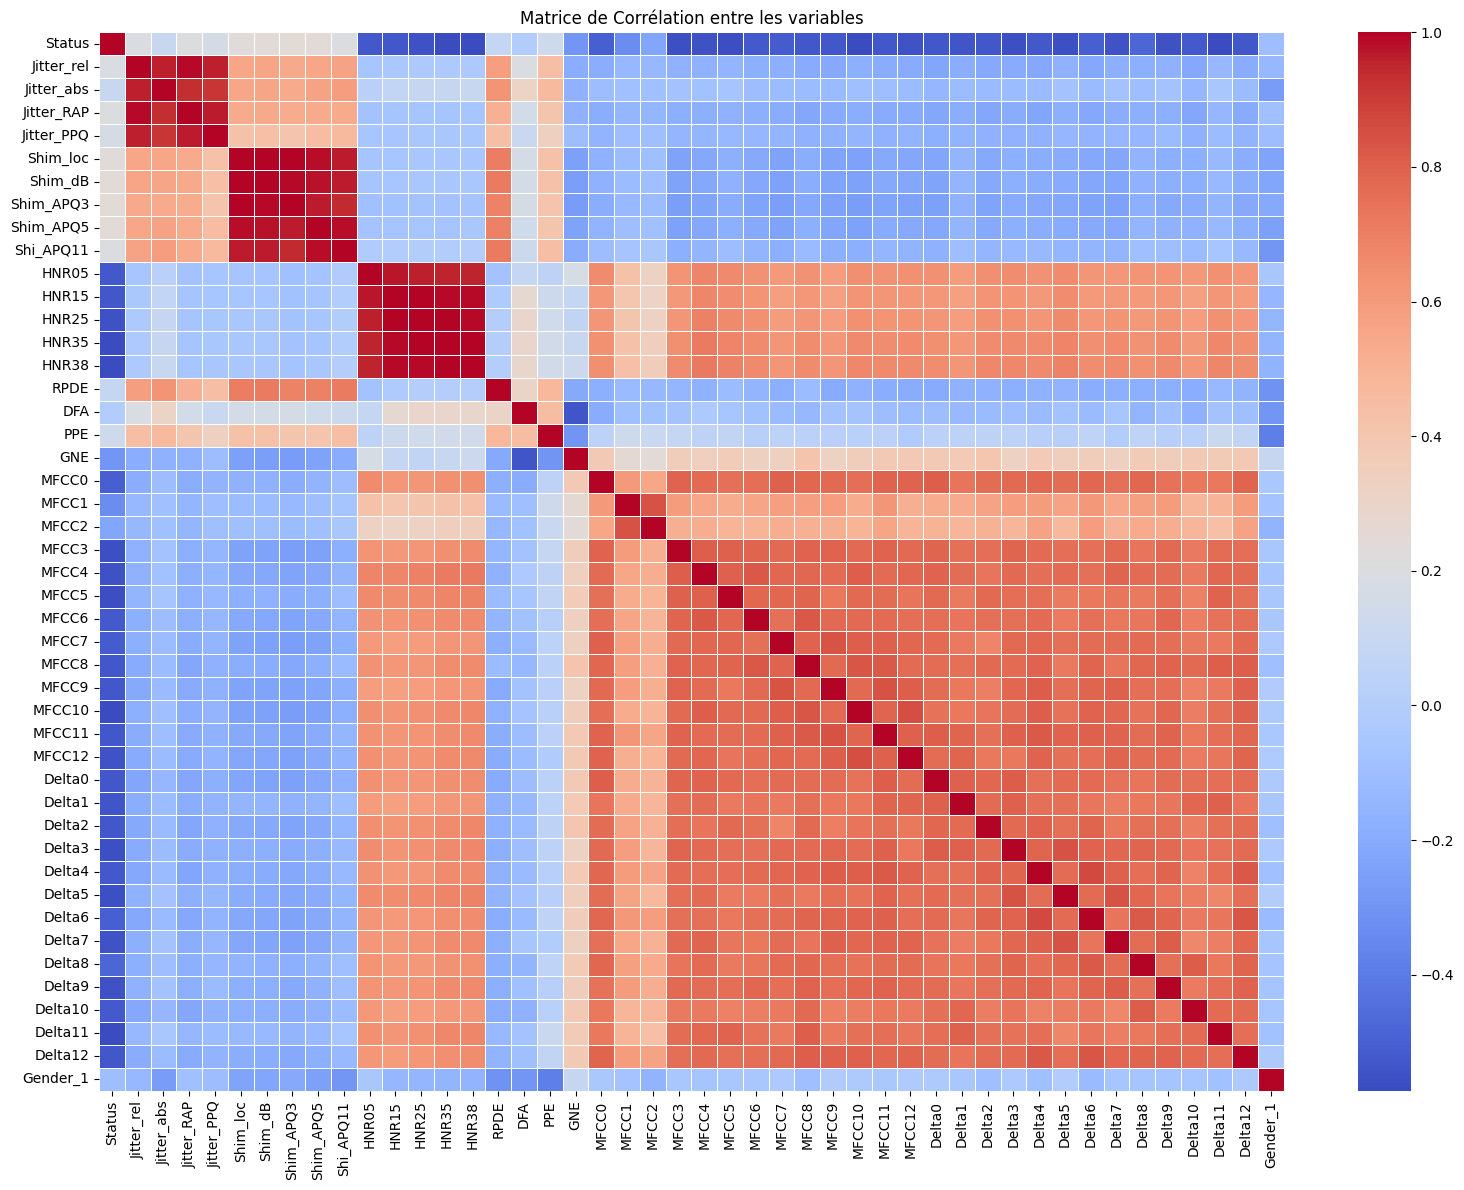

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Chargement du dataset
df = pd.read_csv("parkinson.csv")

# Supprimer les colonnes non numériques ou identifiants
df = df.drop(columns=['ID', 'Recording'])

# Encodage si nécessaire (ex: 'Gender')
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

# Calcul de la matrice de corrélation
correlation_matrix = df.corr()

# Heatmap avec seaborn
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title("Matrice de Corrélation entre les variables")
plt.tight_layout()
plt.show()


sklearn

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, NuSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from IPython.display import display

# Chargement des données
df = pd.read_csv("parkinson.csv")
X = df.drop(columns=['ID', 'Recording', 'Status'])
y = df['Status']
X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

# Calcul des corrélations avec la cible
cor_matrix = pd.concat([X, y], axis=1).corr()
target_corr = cor_matrix["Status"].drop("Status").abs().sort_values(ascending=False)

# Étape de sélection CFS simulée :
# 1. Garder les features les plus corrélées à la cible (top 20)
# 2. Supprimer celles fortement corrélées entre elles (> 0.9)
selected_features = []
for feature in target_corr.index:
    if all(abs(X[feature].corr(X[sel])) < 0.9 for sel in selected_features):
        selected_features.append(feature)
    if len(selected_features) >= 20:
        break

# Sélection finale des features
X_cfs = X[selected_features]

# Normalisation
from sklearn.model_selection import cross_val_score

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[selected_features])

# Modèles
classifiers = {
    "Naïve Bayes": GaussianNB(),
    "SVM (C-SVM)": SVC(kernel='rbf', probability=True, random_state=42),
    "SVM (nu-SVM)": NuSVC(probability=True, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Évaluation avec validation croisée 10-fold
def evaluate_model_cv(model, X, y, cv=10):
    return {
        "Accuracy": cross_val_score(model, X, y, cv=cv, scoring='accuracy').mean(),
        "Precision": cross_val_score(model, X, y, cv=cv, scoring='precision').mean(),
        "Recall": cross_val_score(model, X, y, cv=cv, scoring='recall').mean(),
        "F1-score": cross_val_score(model, X, y, cv=cv, scoring='f1').mean()
    }

results_cv = []
for name, clf in classifiers.items():
    scores = evaluate_model_cv(clf, X_scaled, y)
    scores["Model"] = name
    results_cv.append(scores)

# Affichage
results_df_cv = pd.DataFrame(results_cv).set_index("Model").round(4)
print(" Résultats avec CFS (simulé) + Validation croisée 10-fold :")
display(results_df_cv)

print("\n Features sélectionnées (CfsSubsetEval simulé) :")
print(selected_features)


 Résultats avec CFS (simulé) + Validation croisée 10-fold :


,Accuracy,Precision,Recall,F1-score
Model,,,,
Naïve Bayes,0.8000,0.8270,0.7917,0.7858
SVM (C-SVM),0.7833,0.7956,0.7917,0.7750
SVM (nu-SVM),0.8000,0.8004,0.8250,0.7921
MLP,0.7625,0.7971,0.7333,0.7433
KNN,0.7583,0.7796,0.7500,0.7456
Random Forest,0.7667,0.7933,0.7417,0.7419



 Features sélectionnées (CfsSubsetEval simulé) :
['MFCC10', 'HNR35', 'Delta11', 'MFCC5', 'MFCC3', 'Delta3', 'Delta5', 'Delta9', 'MFCC4', 'MFCC12', 'Delta7', 'Delta1', 'MFCC8', 'Delta2', 'MFCC11', 'Delta12', 'Delta0', 'MFCC9', 'Delta4', 'MFCC6']


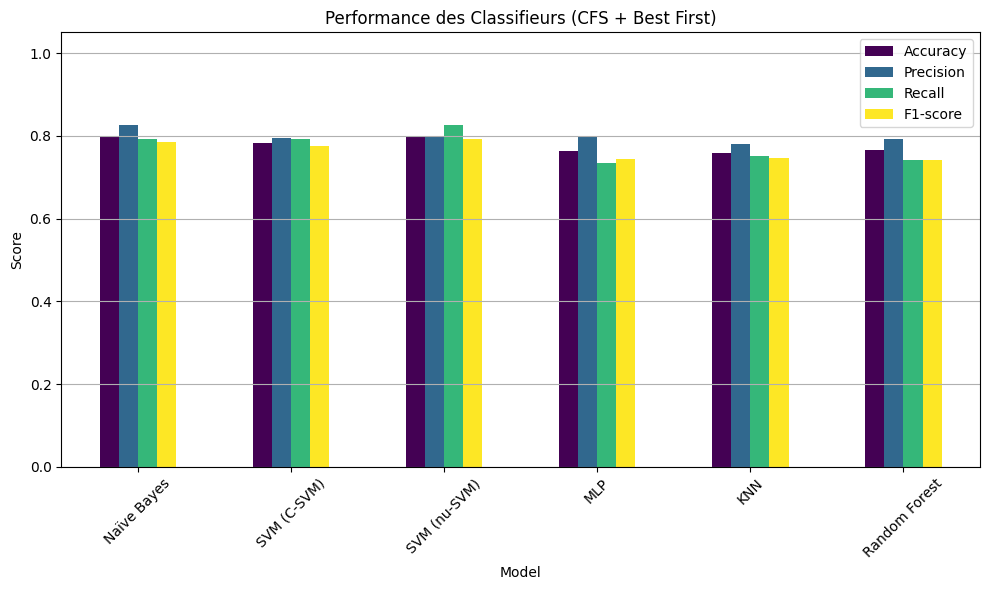

In [10]:
import matplotlib.pyplot as plt

# Barplot
results_df_cv.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title("Performance des Classifieurs (CFS + Best First)")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Gredy Stepwise

 Résultats (Validation croisée 10-fold) avec sélection de caractéristiques (PSO simulé via SFS + RF)


,Accuracy,Precision,Recall,F1-score
Model,,,,
Naïve Bayes,0.8125,0.8253,0.8167,0.8000
SVM (C-SVM),0.7792,0.8316,0.7417,0.7567
SVM (nu-SVM),0.7917,0.8430,0.7583,0.7720
MLP,0.7417,0.7714,0.7417,0.7307
KNN,0.7750,0.8095,0.7667,0.7679
Random Forest,0.8000,0.8289,0.7750,0.7814



 Features sélectionnées (PSO method simulé) :
['MFCC10', 'HNR35', 'Delta11', 'MFCC5', 'MFCC3', 'Delta3', 'Delta5', 'Delta9', 'MFCC4', 'MFCC12', 'Delta7', 'Delta1', 'MFCC8', 'Delta2', 'MFCC11', 'Delta12', 'Delta0', 'MFCC9', 'Delta4', 'MFCC6']


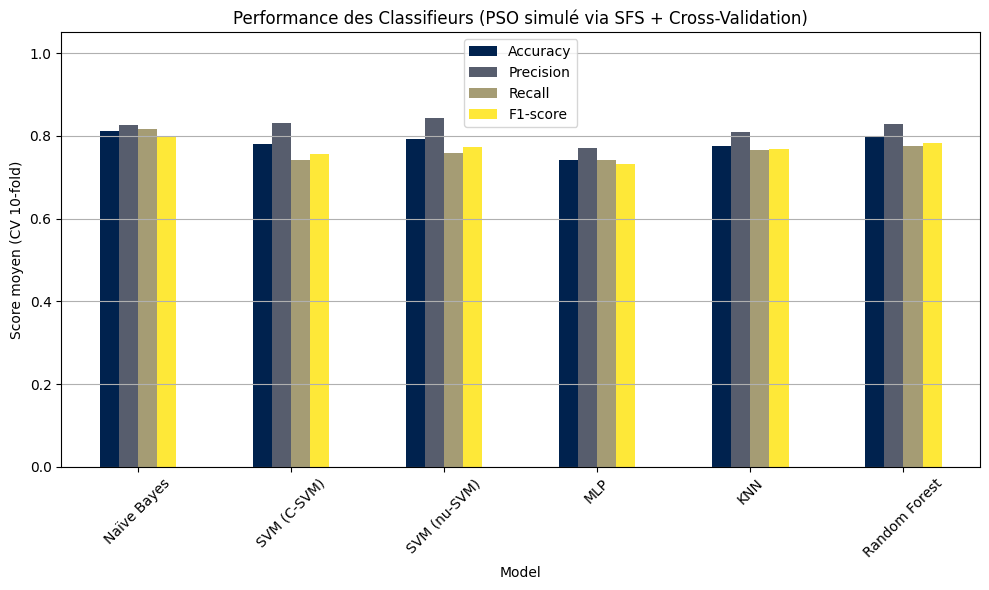

: 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, NuSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Chargement et préparation
df = pd.read_csv("parkinson.csv")
X = df.drop(columns=['ID', 'Recording', 'Status'])
y = df['Status']
X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

# 2. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
from sklearn.model_selection import cross_val_score

# 5bis. Sélection finale sur tout X_scaled (pas seulement X_train)
X_selected = X_scaled[:, selected_idx]

# 6. Modèles à évaluer
classifiers = {
    "Naïve Bayes": GaussianNB(),
    "SVM (C-SVM)": SVC(kernel='rbf', probability=True, random_state=42),
    "SVM (nu-SVM)": NuSVC(probability=True, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# 7. Évaluation avec validation croisée 10-fold
def evaluate_model_cv(model, X, y, cv=10):
    return {
        "Accuracy": cross_val_score(model, X, y, cv=cv, scoring='accuracy').mean(),
        "Precision": cross_val_score(model, X, y, cv=cv, scoring='precision').mean(),
        "Recall": cross_val_score(model, X, y, cv=cv, scoring='recall').mean(),
        "F1-score": cross_val_score(model, X, y, cv=cv, scoring='f1').mean()
    }

results_cv = []
for name, clf in classifiers.items():
    scores = evaluate_model_cv(clf, X_selected, y)
    scores["Model"] = name
    results_cv.append(scores)

# 8. Affichage
results_df_cv = pd.DataFrame(results_cv).set_index("Model").round(4)
print(" Résultats (Validation croisée 10-fold) avec sélection de caractéristiques (PSO simulé via SFS + RF)")
display(results_df_cv)

print("\n Features sélectionnées (PSO method simulé) :")
print(selected_features)  # .tolist() inutile ici

# 9. Graphe
results_df_cv.plot(kind='bar', figsize=(10, 6), colormap='cividis')
plt.title("Performance des Classifieurs (PSO simulé via SFS + Cross-Validation)")
plt.ylabel("Score moyen (CV 10-fold)")
plt.ylim(0, 1.05)
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


PSo Method

 Résultats (Validation croisée 10-fold) avec sélection de caractéristiques (PSO simulé via SFS + RF)


,Accuracy,Precision,Recall,F1-score
Model,,,,
Naïve Bayes,0.8125,0.8253,0.8167,0.8000
SVM (C-SVM),0.7792,0.8316,0.7417,0.7567
SVM (nu-SVM),0.7917,0.8430,0.7583,0.7720
MLP,0.7417,0.7714,0.7417,0.7307
KNN,0.7750,0.8095,0.7667,0.7679
Random Forest,0.8000,0.8289,0.7750,0.7814



 Features sélectionnées (PSO simulé avec SFS sur RF) :
['MFCC10', 'HNR35', 'Delta11', 'MFCC5', 'MFCC3', 'Delta3', 'Delta5', 'Delta9', 'MFCC4', 'MFCC12', 'Delta7', 'Delta1', 'MFCC8', 'Delta2', 'MFCC11', 'Delta12', 'Delta0', 'MFCC9', 'Delta4', 'MFCC6']


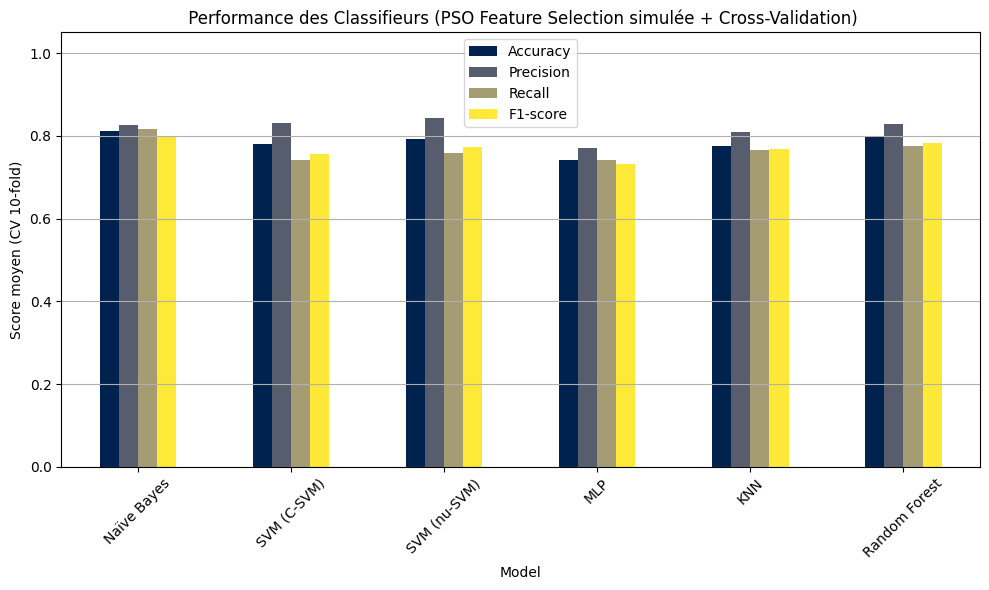

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, NuSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Chargement et préparation
df = pd.read_csv("parkinson.csv")
X = df.drop(columns=['ID', 'Recording', 'Status'])
y = df['Status']
X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

# 2. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
from sklearn.model_selection import cross_val_score

# Remettre ensemble X_scaled (train complet + features sélectionnées)
X_selected = X_scaled[:, selected_idx]

# 6. Classifieurs à évaluer
classifiers = {
    "Naïve Bayes": GaussianNB(),
    "SVM (C-SVM)": SVC(kernel='rbf', probability=True, random_state=42),
    "SVM (nu-SVM)": NuSVC(probability=True, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# 7. Validation croisée 10-fold
def evaluate_model_cv(model, X, y, cv=10):
    return {
        "Accuracy": cross_val_score(model, X, y, cv=cv, scoring='accuracy').mean(),
        "Precision": cross_val_score(model, X, y, cv=cv, scoring='precision').mean(),
        "Recall": cross_val_score(model, X, y, cv=cv, scoring='recall').mean(),
        "F1-score": cross_val_score(model, X, y, cv=cv, scoring='f1').mean()
    }

results_cv = []
for name, clf in classifiers.items():
    scores = evaluate_model_cv(clf, X_selected, y)
    scores["Model"] = name
    results_cv.append(scores)

# 8. Affichage
results_df_cv = pd.DataFrame(results_cv).set_index("Model").round(4)
print(" Résultats (Validation croisée 10-fold) avec sélection de caractéristiques (PSO simulé via SFS + RF)")
display(results_df_cv)

print("\n Features sélectionnées (PSO simulé avec SFS sur RF) :")
print(selected_features)

# 9. Graphe
results_df_cv.plot(kind='bar', figsize=(10, 6), colormap='cividis')
plt.title(" Performance des Classifieurs (PSO Feature Selection simulée + Cross-Validation)")
plt.ylabel("Score moyen (CV 10-fold)")
plt.ylim(0, 1.05)
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
